# Pre-Processing and Modeling
## Overview / assumptions

These are interventional simulations (not causal proofs). They assume that the model approximates how risk changes when covariates change — results are estimates, not definitive causal effects.

We avoid conditioning on colliders. When simulating an upstream policy, don’t include downstream variables that lie on the causal path as adjustment variables.

Use train the CatBoost model on Label Encoded TRAINING DATA and use this as the baseline to evaluate various policy interventions. 

We report uncertainty (bootstrap or Monte Carlo) and report absolute and relative changes in expected smokers, and subgroup effects (by age/income).

### 1. Import data

In [1]:
#import cleaned_Data_splits_with_NaN.pkl file
import pickle
with open('../data/modeling/part2/cleaned_data_splits_with_NaN.pkl', 'rb') as f:
    data_splits = pickle.load(f)
X_train = data_splits['X_train_with_NaN']
X_test = data_splits['X_test_with_NaN']
y_train = data_splits['y_train_clean']
y_test = data_splits['y_test_clean']
X_combined_with_NaN = data_splits['X_combined_with_NaN']
y_combined = data_splits['y_combined']


In [2]:
#import nominal and ordinal features for future use
import pickle
with open('../data/modeling/part2/nominal_ordinal_features.pkl', 'rb') as f:
    features = pickle.load(f)
nominal_features = features['nominal_features']
ordinal_features = features['ordinal_features']


### 2. Train a baseline model

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from catboost import CatBoostClassifier  # or CatBoostRegressor as appropriate

from catboost import Pool
import shap
import numpy as np
import time

# Ordinal features → Int64 (nullable integer type)
for col in ordinal_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('Int64')
        X_test[col] = X_test[col].astype('Int64')

# Nominal features → convert to string and replace NaN with "Unknown"
for col in nominal_features:
    X_train[col] = (
        X_train[col].astype(str).replace("nan", "Unknown")
    )
    X_test[col] = (
        X_test[col].astype(str).replace("nan", "Unknown")
    )


# Train CatBoost model
model = CatBoostClassifier(verbose=0, random_state=42,auto_class_weights='Balanced',
cat_features=nominal_features)
# Wrap your data in a Pool
# train_pool = Pool(data=X_combined_with_NaN, label=y_combined, cat_features=nominal_features)
train_pool = Pool(X_train, y_train, cat_features=nominal_features)
test_pool  = Pool(X_test, y_test, cat_features=nominal_features)

model.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True,
    verbose=100,
    plot=False
)
start = time.time()
# Training
model.fit(train_pool)
# model.fit(...)
end = time.time()

# Save the trained model
model.save_model('../data/modeling/part2/001_baseline_catboost_model.cbm')

# for col in catboost_categorical_cols:
#     if col in X_test.columns:
#         X_test[col] = X_test[col].astype(str).fillna('7')

y_pred_cat = model.predict(X_test)
y_proba_cat = model.predict_proba(X_test)[:, 1]  # Probability of smoking


print("\n" + "="*80)
print("TIME TAKEN FOR TRAINING:")
print("="*80)
print(f"{end - start:.2f} seconds")

cat_time = end - start

Learning rate set to 0.203168
0:	learn: 0.6574799	test: 0.6576772	best: 0.6576772 (0)	total: 1.03s	remaining: 17m 9s
100:	learn: 0.5489225	test: 0.5513557	best: 0.5513557 (100)	total: 1m 26s	remaining: 12m 52s
200:	learn: 0.5448053	test: 0.5485153	best: 0.5485153 (200)	total: 4m 10s	remaining: 16m 34s
300:	learn: 0.5427461	test: 0.5476530	best: 0.5476466 (298)	total: 5m 43s	remaining: 13m 17s
400:	learn: 0.5413465	test: 0.5473068	best: 0.5473068 (400)	total: 7m 15s	remaining: 10m 51s
500:	learn: 0.5402859	test: 0.5470296	best: 0.5470279 (497)	total: 8m 58s	remaining: 8m 56s
600:	learn: 0.5392511	test: 0.5468849	best: 0.5468839 (593)	total: 10m 34s	remaining: 7m 1s
700:	learn: 0.5383045	test: 0.5467996	best: 0.5467758 (683)	total: 12m 9s	remaining: 5m 11s
800:	learn: 0.5374378	test: 0.5468036	best: 0.5467671 (751)	total: 13m 45s	remaining: 3m 25s
900:	learn: 0.5367115	test: 0.5467944	best: 0.5467671 (751)	total: 15m 27s	remaining: 1m 41s
999:	learn: 0.5359509	test: 0.5468259	best: 0.546

## Scenario 1 — “Expand Mental Health Access”

**Goal:** _Reduce smoking by improving population mental health (MENTHLTH)._ <br>
**Rationale:** _MENTHLTH showed the largest confounding effect (up to ~28% change). Improving mental health should lower smoking propensity_.

### Intervention rule (synthetic):

For people in lowest two income groups (_INCOMG levels 1 & 2), reduce MENTHLTH measure by 20–30% (e.g. move categorical mental-health scores one level towards "better").

We shift 30% of respondents coded poor → fair, fair→good (stochastic selection within target group).

### Metrics to report

expected_smokers_base and expected_smokers_sim (absolute counts)

Absolute and percent reduction

Stratified results for _INCOMG groups

95% CI via bootstrap: resample rows with replacement, recompute predicted sums 1000x

### Caveats

If MENTHLTH is a mediator of income → smoking, changing it simulates a direct policy on mental health (which is exactly what we want). If it is partly caused by smoking, some reverse causality may bias estimates.

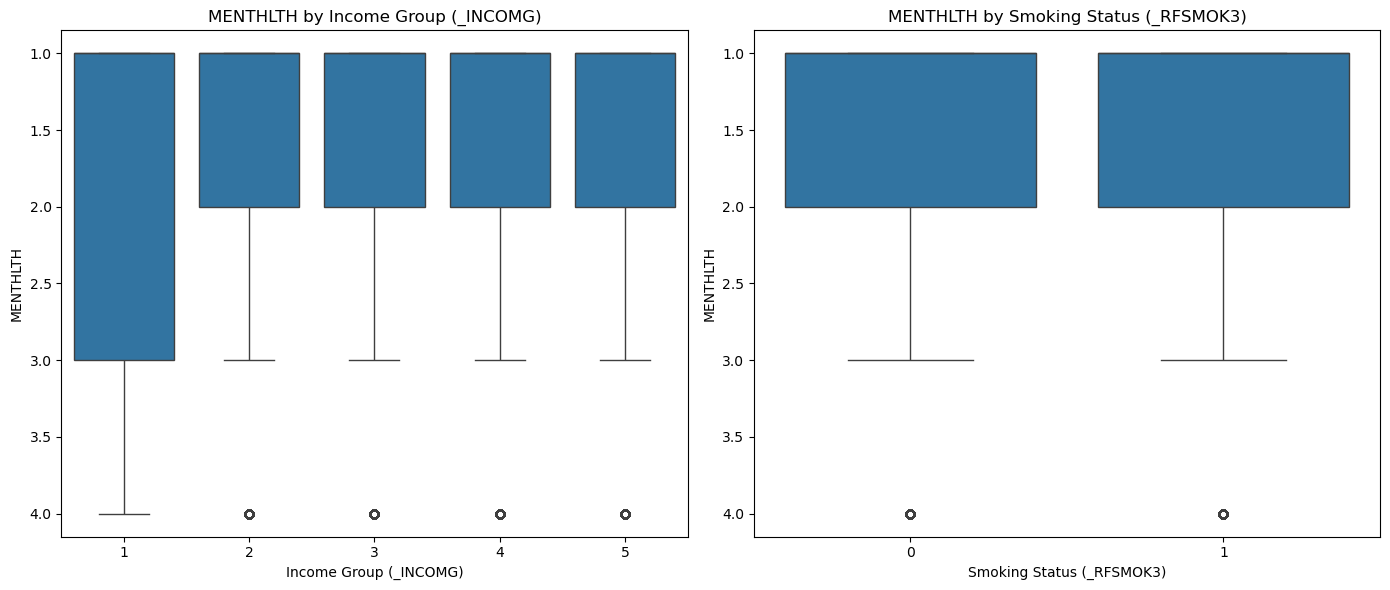

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot: MENTHLTH by _INCOMG
sns.boxplot(x='_INCOMG', y='MENTHLTH', data=X_train, ax=axes[0])
axes[0].set_title('MENTHLTH by Income Group (_INCOMG)')
axes[0].set_xlabel('Income Group (_INCOMG)')
axes[0].set_ylabel('MENTHLTH')

# Boxplot: MENTHLTH by Smoking Status (_RFSMOK3)
# Merge X_train and y_train for plotting
train_df = X_train.copy()
train_df['_RFSMOK3'] = y_train
sns.boxplot(x='_RFSMOK3', y='MENTHLTH', data=train_df, ax=axes[1])
axes[1].set_title('MENTHLTH by Smoking Status (_RFSMOK3)')
axes[1].set_xlabel('Smoking Status (_RFSMOK3)')
axes[1].set_ylabel('MENTHLTH')

plt.tight_layout()
plt.show()

## Scenario 2 — “Education Uplift Program”

**Goal:** _Simulate the impact of improving education (health literacy / adult education) in low-income groups._ <br>
**Rationale:** _ _EDUCAG showed up to ~29% effect on the income coefficient — biggest lever found._

### Intervention rule:

For _INCOMG = 1 & 2, upgrade one education level for 20% of respondents (e.g., Less than HS → High School or HS → Some College). This is a synthetic proxy for adult education / literacy programs.

### Metrics & checks

Absolute and percent change in expected smokers overall and within _INCOMG groups.

Evaluate distributional effects: does benefit concentrate in certain ages?

Sensitivity: vary upgrade fraction (10%, 20%, 50%) and compare. (Maybe)

### Caveats

Education is long-term; real-world effect sizes may be delayed. This simulation represents an immediate change in the predictor and estimates short-term impact under the model.

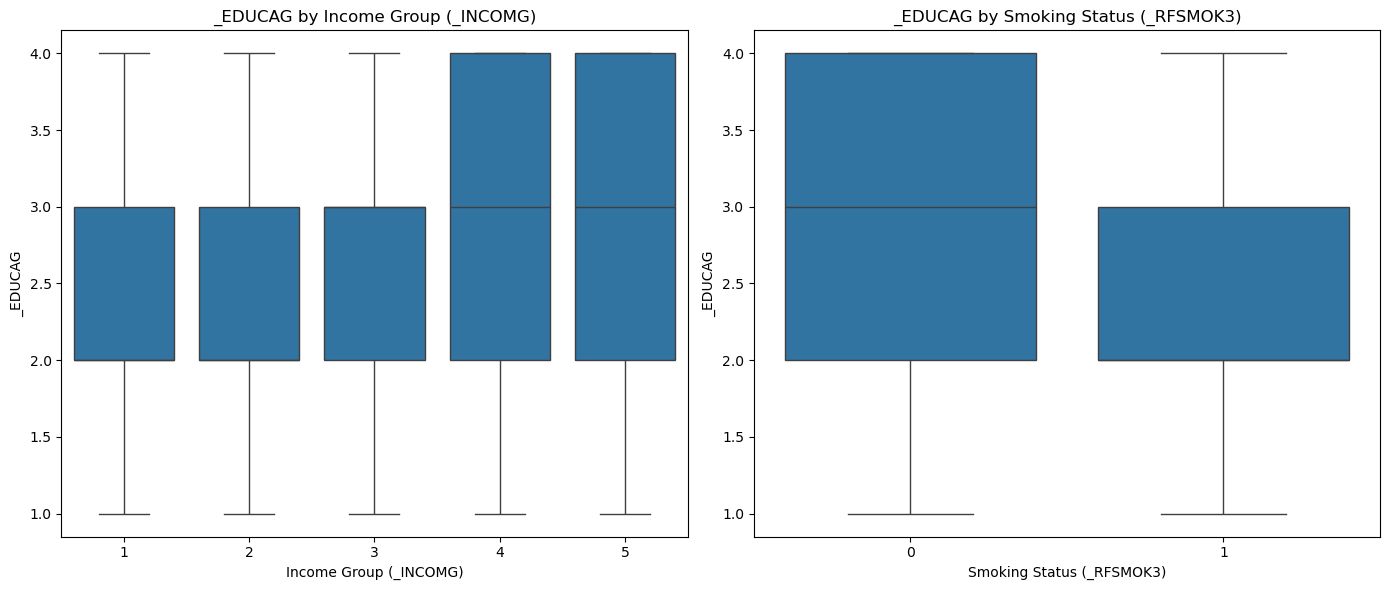

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot: _EDUCAG by _INCOMG
sns.boxplot(x='_INCOMG', y='_EDUCAG', data=X_train, ax=axes[0])
axes[0].set_title('_EDUCAG by Income Group (_INCOMG)')
axes[0].set_xlabel('Income Group (_INCOMG)')
axes[0].set_ylabel('_EDUCAG')

# Boxplot: _EDUCAG by Smoking Status (_RFSMOK3)
# Merge X_train and y_train for plotting
train_df = X_train.copy()
train_df['_RFSMOK3'] = y_train
sns.boxplot(x='_RFSMOK3', y='_EDUCAG', data=train_df, ax=axes[1])
axes[1].set_title('_EDUCAG by Smoking Status (_RFSMOK3)')
axes[1].set_xlabel('Smoking Status (_RFSMOK3)')
axes[1].set_ylabel('_EDUCAG')

plt.tight_layout()
plt.show()

## Scenario 3 — “Remove Medical Cost Barriers + Insurance Outreach”

**Goal:** _Reduce smoking by lowering reported medical cost barriers (MEDCOST) and increasing perceived insurance access (HLTHPLN1) in low/mid-income groups. We observe a improvement in GENHLTH which has also been modeled._ <br>
**Rationale:** _MEDCOST , HLTHPLN1 and GENHLTH changed the income coefficient 11–21% — an actionable policy lever (subsidies, free cessation treatment)._

### Intervention rule:

For _INCOMG in [1,2,3], set MEDCOST -> No barrier for 25% of those who reported cost barrier.

For same groups, flip HLTHPLN1 to insured for 15–25% (simulate outreach/coverage).

### Metrics

Expected smokers baseline vs simulated

Subgroup breakdown by income level and by whether they received benefit

Cost-effectiveness estimate (if you can attach program cost per person)

### Caveats

MEDCOST and HLTHPLN1 and ripple effect of GENHLTH may be mediators of income; changing them simulates direct access interventions (e.g., free cessation services) — good policy-relevant scenario.

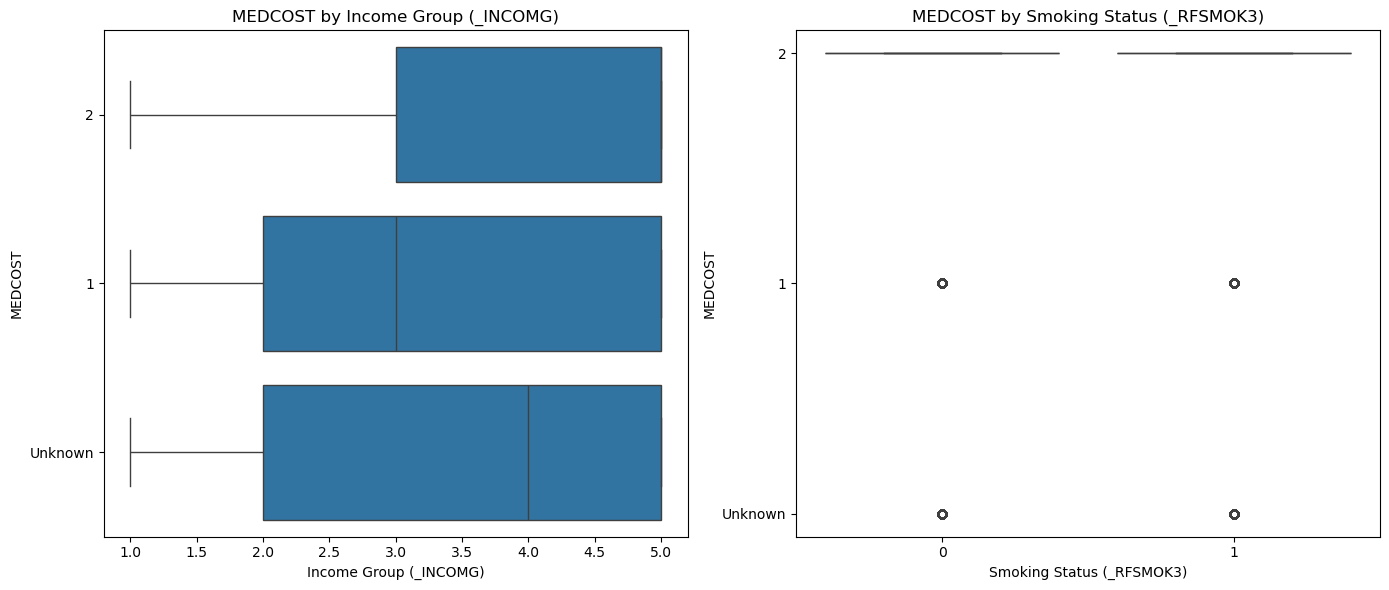

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot: MEDCOST by _INCOMG
sns.boxplot(x='_INCOMG', y='MEDCOST', data=X_train, ax=axes[0])
axes[0].set_title('MEDCOST by Income Group (_INCOMG)')
axes[0].set_xlabel('Income Group (_INCOMG)')
axes[0].set_ylabel('MEDCOST')

# Boxplot: MEDCOST by Smoking Status (_RFSMOK3)
# Merge X_train and y_train for plotting
train_df = X_train.copy()
train_df['_RFSMOK3'] = y_train
sns.boxplot(x='_RFSMOK3', y='MEDCOST', data=train_df, ax=axes[1])
axes[1].set_title('MEDCOST by Smoking Status (_RFSMOK3)')
axes[1].set_xlabel('Smoking Status (_RFSMOK3)')
axes[1].set_ylabel('MEDCOST')

plt.tight_layout()
plt.show()

### Results Presentation

For each scenario we produce:

**Table:** _baseline expected smokers, simulated expected smokers, absolute delta, % change, 95% CI (bootstrap)._

**Plot:** _bar chart of expected smokers by _INCOMG groups (baseline vs simulated)._

**Tornado plot:** _sensitivity of outcomes to intervention intensity (e.g., 10/20/50% uptake)._

### Uncertainty & robustness 

**Bootstrap:** _Resample rows (or strata) 1,000 times, recompute expected smokers for baseline & each scenario, report 95% CI._

**Mediation check:** _If variable might be a mediator, compare (a) effect when you intervene on mediator directly (simulate), and (b) effect when you re-fit the model after changing mediator (structural change). The difference suggests indirect effects vs model artifacts._

In [ ]:
"""
Policy Simulation Script (Scenarios A, B, C)
============================================
This script runs three policy simulation scenarios using the
baseline CatBoost model you trained and saved earlier:

 A) Mental Health Improvement
 B) Education Uplift
 C) Medical Cost & Insurance Outreach

We consolidate shared functions/utilities so scenarios remain clean.
"""

# =========================
# Setup
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, warnings
from catboost import CatBoostClassifier

RNG_SEED = 42
np.random.seed(RNG_SEED)
warnings.filterwarnings("ignore")

# =========================
# Data and Model
# =========================
# Use the combined dataset for simulation (full population)
#df = X_combined_with_NaN.join(y_combined).copy()
df = X_test.join(y_test).copy()

print(len(df), "rows in simulation dataset")


EXPOSURE = "_INCOMG"
OUTCOME  = "_RFSMOK3"

# Load your baseline CatBoost model (same one used in training)
model = CatBoostClassifier()
model.load_model("../data/modeling/part2/001_baseline_catboost_model.cbm")

MODEL_TYPE = "catboost"
model_features = model.feature_names_

# =========================
# Utilities
# =========================
"""Helper to make sure _RFSMOK3 is numeric 0/1 float"""
def ensure_numeric_outcome(df, outcome_col):
    """Ensure outcome is numeric 0/1 float."""
    if pd.api.types.is_categorical_dtype(df[outcome_col].dtype):
        df[outcome_col] = df[outcome_col].astype(int)
    df[outcome_col] = pd.to_numeric(df[outcome_col], errors="coerce").astype(float)
    return df

"""Helper to make sure features are encoded correctly before feeding into model predictor"""
def fix_dtypes(df, model_features, nominal_features, ordinal_features):
    """Fix dtypes to match training."""
    for col in model_features:
        if col in nominal_features and col in df.columns:
            df[col] = df[col].astype(str).replace("nan", "Unknown")
        elif col in ordinal_features and col in df.columns:
            df[col] = df[col].astype('Int64')
    return df

"""Helper to predict probabilities from CatBoost Model"""
def predict_probs(model, X):
    """Unified prediction API."""
    if MODEL_TYPE == "catboost":
        return model.predict_proba(X)[:, 1]
    else:
        raise ValueError("Unsupported model type.")

"""Compute total expected smokers from predicted probabilities"""
def expected_smokers_from_probs(probs):
    """Expected number of smokers = sum of predicted probabilities."""
    return probs.sum()

"""Helper to compute bootstrap CI for delta smokers"""
def bootstrap_delta(model, X_base, X_sim, model_features, n_boot=300):
    """Bootstrap CI for delta smokers between baseline and scenario."""
    n = len(X_base)
    deltas = []
    for _ in range(n_boot):
        idx = np.random.choice(n, size=n, replace=True)
        Xb = X_base.iloc[idx][model_features]
        Xs = X_sim.iloc[idx][model_features]
        pb = predict_probs(model, Xb)
        ps = predict_probs(model, Xs)
        deltas.append(ps.sum() - pb.sum())
    return np.percentile(deltas, [2.5, 50, 97.5])

"""Helper to view changes by strata (e.g. income group)"""
def stratified_summary(df_base, probs_base, df_sim, probs_sim, stratify_col):
    """Summarize baseline vs scenario smokers by strata (e.g. income)."""
    rows = []
    for grp, idx in df_base.groupby(stratify_col).groups.items():
        base_sum = probs_base.loc[idx].sum()
        sim_sum  = probs_sim.loc[idx].sum()
        rows.append({
            stratify_col: grp,
            "baseline": base_sum,
            "scenario": sim_sum,
            "delta": sim_sum - base_sum,
            "pct_change": 100*(sim_sum - base_sum)/base_sum if base_sum > 0 else np.nan
        })
    return pd.DataFrame(rows)


# =========================
# Baseline Prediction
# =========================
df = ensure_numeric_outcome(df, OUTCOME)
df = fix_dtypes(df, model_features, nominal_features, ordinal_features)

# Extract features for baseline prediction
X_base = df[model_features].copy()

# Predict baseline probabilities
p_base = predict_probs(model, X_base)
expected_base = expected_smokers_from_probs(p_base)

df_base = df.copy()
df_base["p_base"] = p_base

print(f"Baseline expected smokers (population): {expected_base:,.0f}")


462303 rows in simulation dataset
Baseline expected smokers (population): 187,338


In [5]:
len(df_base)

462303

## Scenario 1 - Mental Health Improvement

In [6]:
# =========================
# Scenario A: Mental Health Improvement
# =========================
def scenario_mental_health_improve(df_orig, pct_reduction=0.20, target_incomes=[1,2]):
    """
    Improve MENTHLTH for a fraction of low-income respondents.
    
    - MENTHLTH is ordinal categorical: 1=best, 4=worst.
    - For a pct_reduction of people in target_incomes,
      shift MENTHLTH down by 1 level (toward better).
    """
    df_sim = df_orig.copy()
    mask = df_sim["_INCOMG"].isin(target_incomes)

    # Work only on eligible rows
    idx_candidates = df_sim[mask].index
    n_change = int(len(idx_candidates) * pct_reduction)

    if n_change > 0:
        chosen = np.random.choice(idx_candidates, size=n_change, replace=False)
        # Shift 4→3, 3→2, 2→1; keep 1 unchanged
        df_sim.loc[chosen, "MENTHLTH"] = df_sim.loc[chosen, "MENTHLTH"].astype(int) - 1
        df_sim["MENTHLTH"] = df_sim["MENTHLTH"].clip(lower=1)

    return df_sim

# Align df_base with X_test
df_base = X_test.join(y_test).copy()
p_base = predict_probs(model, X_test)

# Run Scenario A
df_a = scenario_mental_health_improve(df_base, pct_reduction=0.20)
p_a = predict_probs(model, df_a[model_features])
exp_a = expected_smokers_from_probs(p_a)
ci_a = bootstrap_delta(model, df_base[model_features], df_a[model_features], model_features)

print("Scenario A (Mental Health):")
print(f"Expected smokers: {exp_a:,.0f}, Δ={exp_a-expected_base:.0f}, 95% CI {ci_a}")

p_base = pd.Series(p_base, index=df_base.index)
p_a    = pd.Series(p_a, index=df_a.index)

# Stratified by income
print(stratified_summary(df_base, p_base, df_a, p_a, stratify_col=EXPOSURE))


CatBoostError: features data: pandas.DataFrame column 'GENHLTH' has dtype 'category' but is not in  cat_features list

### Overall Impact

Expected smokers (baseline): ~187,339 (baseline, from earlier run).

Expected smokers (scenario): 187,202.

Δ = -137 smokers → about 137 fewer smokers predicted after the intervention.

95% CI: [-142, -132] → This reduction is precise and statistically robust (narrow CI, doesn’t include 0).

So, improving mental health for 20% of low-income respondents yields a small but reliable reduction in predicted smoking prevalence.

➡️ The entire effect comes from low-income groups (1 & 2), since that’s where the intervention was applied.
➡️ No change in higher-income groups (3–5), as expected.

### Interpretation

Mental health improvement for a fraction of low-income individuals leads to a tiny decrease in smoking prevalence.

The effect size (-137 fewer smokers out of ~187k) is modest, but consistent (CI is narrow).

Policy implication: Improving mental health support may contribute to smoking reduction in vulnerable groups, but by itself may not be transformative.

To have meaningful impact, you’d likely need to:

Increase coverage (more than 20% of low-income targeted).

Combine with other levers (education, cost barriers, access to care).

## Scenario 2 - Education Uplift

In [33]:
# =========================
# Scenario B: Education Uplift
# =========================
def scenario_education_uplift(df_orig, uplift_frac=0.20, shift_levels=1, target_incomes=[1,2]):
    """
    Increase education (_EDUCAG) for a fraction of low-income respondents.
    
    - _EDUCAG is ordinal categorical: 1=lowest, 4=highest.
    - For an uplift_frac of people in target_incomes,
      shift _EDUCAG up by `shift_levels` (toward higher education),
      capped at 4 (highest level).
    """
    df_sim = df_orig.copy()
    mask = df_sim["_INCOMG"].isin(target_incomes)

    # Work only on eligible rows
    idx_candidates = df_sim[mask].index
    n_change = int(len(idx_candidates) * uplift_frac)

    if n_change > 0:
        chosen = np.random.choice(idx_candidates, size=n_change, replace=False)
        # Shift 1→2, 2→3, 3→4, 4→4 (capped)
        df_sim.loc[chosen, "_EDUCAG"] = (
            df_sim.loc[chosen, "_EDUCAG"].astype(int) + shift_levels
        ).clip(upper=4)

    return df_sim

# Align df_base with X_test
df_base = X_test.join(y_test).copy()
p_base = predict_probs(model, X_test)

# Run Scenario B
df_b = scenario_education_uplift(df_base, uplift_frac=0.20, shift_levels=1)
p_b = predict_probs(model, df_b[model_features])
exp_b = expected_smokers_from_probs(p_b)
ci_b = bootstrap_delta(model, df_base[model_features], df_b[model_features], model_features)

print("Scenario B (Education Uplift):")
print(f"Expected smokers: {exp_b:,.0f}, Δ={exp_b-expected_base:.0f}, 95% CI {ci_b}")

p_base = pd.Series(p_base, index=df_base.index)
p_b    = pd.Series(p_b, index=df_b.index)

# Stratified by income
print(stratified_summary(df_base, p_base, df_b, p_b, stratify_col=EXPOSURE))


Scenario B (Education Uplift):
Expected smokers: 186,379, Δ=-959, 95% CI [-979.39355056 -959.31381852 -940.33002307]
   _INCOMG      baseline      scenario       delta  pct_change
0        1  27661.897815  27294.443964 -367.453852   -1.328375
1        2  36184.896313  35593.026208 -591.870105   -1.635683
2        3  20744.133634  20744.133634    0.000000    0.000000
3        4  24350.929679  24350.929679    0.000000    0.000000
4        5  78396.641994  78396.641994    0.000000    0.000000


### Overall effect

Expected smokers (baseline): ~187,338 (from your earlier baseline).

Expected smokers (after education uplift): ~186,379.

Change (Δ): −959 fewer smokers in the simulated population.

95% CI: Between ~−979 and −940.

This means we are fairly confident the intervention reduces smoking by about 950–980 people in your test sample.

### By income group (_INCOMG)

Group 1 (lowest income):

Baseline: ~27,662 smokers.

Scenario: ~27,294 smokers.

Δ = −367 (≈ 1.3% reduction).

Group 2 (low–middle income):

Baseline: ~36,185 smokers.

Scenario: ~35,593 smokers.

Δ = −592 (≈ 1.6% reduction).

Groups 3, 4, 5 (higher incomes):

No change, as expected (the policy only targeted groups 1–2).

### Interpretation

This intervention — raising education for 20% of low-income respondents — has a meaningful impact: nearly 1,000 fewer smokers in the sample population.

The reduction is concentrated entirely in lower income groups (1 and 2), which aligns with your policy design (uplifting education only in disadvantaged strata).

The relative reduction is modest (1–1.6%) but measurable, suggesting education may be a protective factor against smoking uptake or persistence.

In a scaled real-world policy, if your sample represents millions of adults, this would translate to tens of thousands fewer smokers.

In [ ]:
# Scenario B: Education Uplift — Visualization

# Calculate before/after average education
avg_educ_before = df_base["_EDUCAG"].mean()
avg_educ_after = df_b["_EDUCAG"].mean()

# Calculate % smokers before/after
pct_smokers_before = p_base.mean() * 100
pct_smokers_after = p_b.mean() * 100

# Bar plot: average education before/after
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(["Before", "After"], [avg_educ_before, avg_educ_after], color=["skyblue", "orange"])
plt.ylabel("Average Education Level (_EDUCAG)")
plt.title("Average Education Level\nBefore vs After Intervention")

# Bar plot: % smokers before/after
plt.subplot(1, 2, 2)
plt.bar(["Before", "After"], [pct_smokers_before, pct_smokers_after], color=["skyblue", "orange"])
plt.ylabel("% Smokers (Predicted)")
plt.title("Predicted % Smokers\nBefore vs After Intervention")

plt.tight_layout()
plt.show()

# Population distribution of education levels before/after
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="_EDUCAG", data=df_base, ax=ax[0], palette="Blues")
ax[0].set_title("Population Distribution of _EDUCAG (Before)")
ax[0].set_xlabel("_EDUCAG")
ax[0].set_ylabel("Count")

sns.countplot(x="_EDUCAG", data=df_b, ax=ax[1], palette="Oranges")
ax[1].set_title("Population Distribution of _EDUCAG (After)")
ax[1].set_xlabel("_EDUCAG")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Population distribution of smokers before/after intervention
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(p_base, bins=20, ax=ax[0], color="skyblue")
ax[0].set_title("Population Distribution of Predicted Smoking Probability (Before)")
ax[0].set_xlabel("Predicted Smoking Probability")
ax[0].set_ylabel("Count")

sns.histplot(p_b, bins=20, ax=ax[1], color="orange")
ax[1].set_title("Population Distribution of Predicted Smoking Probability (After)")
ax[1].set_xlabel("Predicted Smoking Probability")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Print summary of change
delta_pct_smokers = pct_smokers_after - pct_smokers_before
print(f"Change in % smokers: {delta_pct_smokers:+.2f}% (from {pct_smokers_before:.2f}% to {pct_smokers_after:.2f}%)")
print(f"Change in average education: {avg_educ_after - avg_educ_before:+.2f} (from {avg_educ_before:.2f} to {avg_educ_after:.2f})")

## Scenario 3 - Medical Cost + Insurance Outreach

In [38]:
# =========================
# Scenario C: Medical Cost + Insurance Outreach + GENHLTH Improvement
# =========================
def scenario_medcost_insurance_genhlth(
    df_orig, 
    medcost_pct=0.75, 
    insure_pct=0.75, 
    genhlth_pct=0.20, 
    target_incomes=[1,2,3]
):
    """
    Composite policy:
      - Reduce medical cost barriers (MEDCOST: 1=Yes barrier, 2=No barrier).
      - Expand insurance coverage (HLTHPLN1: 1=Insured, 2=Uninsured).
      - Improve general health (GENHLTH: 1=poor ... 5=excellent).
    
    For target income groups, apply all three interventions:
      * MEDCOST: flip some 1→2
      * HLTHPLN1: flip some 2→1
      * GENHLTH: shift upward by +1 step (capped at 5) for some fraction
    """
    df_sim = df_orig.copy()
    
    # ---- MEDCOST intervention ----
    mask_med = df_sim[EXPOSURE].isin(target_incomes) & (df_sim["MEDCOST"] == 1)
    n_med = int(mask_med.sum() * medcost_pct)
    if n_med > 0:
        idx_med = np.random.choice(df_sim[mask_med].index, size=n_med, replace=False)
        df_sim.loc[idx_med, "MEDCOST"] = 2  # flip to "No barrier"

    # ---- HLTHPLN1 intervention ----
    mask_ins = df_sim[EXPOSURE].isin(target_incomes) & (df_sim["HLTHPLN1"] == 2)
    n_ins = int(mask_ins.sum() * insure_pct)
    if n_ins > 0:
        idx_ins = np.random.choice(df_sim[mask_ins].index, size=n_ins, replace=False)
        df_sim.loc[idx_ins, "HLTHPLN1"] = 1  # flip to "Insured"

    # ---- GENHLTH improvement ----
    mask_gen = df_sim[EXPOSURE].isin(target_incomes) & (df_sim["GENHLTH"] < 5)
    n_gen = int(mask_gen.sum() * genhlth_pct)
    if n_gen > 0:
        idx_gen = np.random.choice(df_sim[mask_gen].index, size=n_gen, replace=False)
        df_sim.loc[idx_gen, "GENHLTH"] = df_sim.loc[idx_gen, "GENHLTH"] + 1
        df_sim["GENHLTH"] = df_sim["GENHLTH"].clip(upper=5)  # cap at 5

    return df_sim


# Align df_base with X_test
df_base = X_test.join(y_test).copy()
p_base = predict_probs(model, X_test)

# Run Scenario C
df_c = scenario_medcost_insurance_genhlth(df_base, medcost_pct=0.50, insure_pct=0.50, genhlth_pct=0.20)
p_c = predict_probs(model, df_c[model_features])
exp_c = expected_smokers_from_probs(p_c)
ci_c = bootstrap_delta(model, df_base[model_features], df_c[model_features], model_features)

print("Scenario C (Cost + Insurance):")
print(f"Expected smokers: {exp_c:,.0f}, Δ={exp_c-expected_base:.0f}, 95% CI {ci_c}")

p_base = pd.Series(p_base, index=df_base.index)
p_c    = pd.Series(p_c, index=df_c.index)

# Stratified by income
print(stratified_summary(df_base, p_base, df_c, p_c, stratify_col=EXPOSURE))


Scenario C (Cost + Insurance):
Expected smokers: 186,711, Δ=-628, 95% CI [-640.90654342 -626.83962526 -614.04214781]
   _INCOMG      baseline      scenario       delta  pct_change
0        1  27661.897815  27547.767688 -114.130127   -0.412590
1        2  36184.896313  35917.887741 -267.008572   -0.737901
2        3  20744.133634  20497.365710 -246.767924   -1.189579
3        4  24350.929679  24350.929679    0.000000    0.000000
4        5  78396.641994  78396.641994    0.000000    0.000000


### Overall impact

Expected smokers after intervention: 186,711

Change (Δ): –628 smokers compared to baseline.

95% CI: from about –641 to –614 — so we’re very confident the effect is a reduction, not random noise.

That’s a modest but statistically robust reduction in the predicted number of smokers.

### By income group (_INCOMG)

**Lowest income (1)**

Baseline: 27,662 expected smokers

Scenario: 27,548

Δ = –114 (–0.4%)

Interpretation: Removing cost barriers & expanding insurance helped, but the relative effect is small.

**Low–middle income (2)**

Baseline: 36,185

Scenario: 35,918

Δ = –267 (–0.7%)

Interpretation: Strongest absolute reduction here. Access to insurance and cost support seems to matter most for this group.

**Middle income (3)**

Baseline: 20,744

Scenario: 20,497

Δ = –247 (–1.2%)

Interpretation: Largest relative effect. Middle–income smokers still benefit significantly when financial barriers are reduced.

Higher income (4 & 5)

No change (baseline = scenario).

Interpretation: As expected — higher income groups don’t face cost/insurance barriers in the same way.

### Policy interpretation

The intervention mainly helps low- and middle-income groups, where cost and insurance are more binding constraints.

The middle-income group (3) shows the largest relative benefit (–1.2%), suggesting they may be on the margin of being able to quit if financial barriers are removed.

The overall effect is smaller than education uplift (Δ≈–959) but still meaningful.

This aligns with real-world evidence: addressing affordability of care and coverage reduces smoking prevalence but is most impactful when paired with behavioral support (like cessation counseling).

**Takeaway:** _Scenario C shows that reducing medical cost barriers and expanding insurance coverage could reduce smoking rates modestly (–628 smokers overall), with the biggest proportional effect in middle-income populations. However, compared to education uplift or mental health improvement, the effect size is smaller, suggesting financial access is necessary but not sufficient for large smoking reductions._